In [1]:
import os

if not os.path.exists("pw18-ticketing"):
    !git clone https://github.com/simonaoliveto83/pw18-ticketing.git

Cloning into 'pw18-ticketing'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 67 (delta 15), reused 44 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 2.22 MiB | 12.57 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
import pandas as pd

# caricamento dati
df = pd.read_csv("pw18-ticketing/prototipo3/data/tickets_sintetici.csv")
#df = pd.read_csv("/content/drive/MyDrive/prototipo3/data/tickets_sintetici.csv")


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()  # rimuove spazi extra
    return text

In [5]:
df["text"] = df["title"] + " " + df["body"]
df["title"] = df["title"].fillna("")
df["title"] = df["title"].str.lower()
df["body"] = df["body"].fillna("")
df["body"] = df["body"].str.lower()
df["text"] = df["title"] + " " + df["body"]

# commentata rimozione della punteggiatura perchè peggiorava le performance
# df["text"] = df["text"].apply(clean_text)

In [6]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
# encoding delle etichette
from sklearn.preprocessing import LabelEncoder

le_cat = LabelEncoder()
le_prio = LabelEncoder()

df["category_enc"] = le_cat.fit_transform(df["category"])
df["priority_enc"] = le_prio.fit_transform(df["priority"])


In [8]:
# # train/test split
from sklearn.model_selection import train_test_split

X_temp, X_test, y_cat_temp, y_cat_test, y_prio_temp, y_prio_test = train_test_split(
    df["text"], df["category_enc"], df["priority_enc"],
    test_size=0.2, random_state=42, stratify=df["category_enc"]
)

X_train, X_val, y_cat_train, y_cat_val, y_prio_train, y_prio_val = train_test_split(
    X_temp, y_cat_temp, y_prio_temp,
    test_size=0.125, random_state=42, stratify=y_cat_temp
)

In [9]:
# TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

In [10]:
# conversione in tensori PyTorch
import torch

X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_tfidf.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32)

y_cat_train_tensor = torch.tensor(y_cat_train.values, dtype=torch.long)
y_cat_val_tensor = torch.tensor(y_cat_val.values, dtype=torch.long)
y_cat_test_tensor = torch.tensor(y_cat_test.values, dtype=torch.long)

y_prio_train_tensor = torch.tensor(y_prio_train.values, dtype=torch.long)
y_prio_val_tensor = torch.tensor(y_prio_val.values, dtype=torch.long)
y_prio_test_tensor = torch.tensor(y_prio_test.values, dtype=torch.long)

In [11]:
# conta le classi
class_counts = pd.Series(y_prio_train).value_counts().sort_index()

# inverso delle frequenze
weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float32)

# normalizzazione (opzionale ma consigliata)
weights = weights / weights.sum()

In [12]:
# definizione del modello: multi-task con due teste
#  un solo encoder testuale
#  due teste di classificazione
import torch.nn as nn

class TicketClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        self.cat_head = nn.Linear(128, 3)
        self.prio_head = nn.Linear(128, 3)

    def forward(self, x):
        x = self.shared(x)
        return self.cat_head(x), self.prio_head(x)

In [13]:
# inizializzazione
model = TicketClassifier(X_train_tensor.shape[1])

criterion_cat = nn.CrossEntropyLoss()
criterion_prio = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

#inizializzazione delle liste per relativi grafici
train_losses = []
val_losses = []

cat_accuracies = []
prio_accuracies = []

cat_f1_scores = []
prio_f1_scores = []

In [14]:
# training loop
from sklearn.metrics import accuracy_score, f1_score

best_val_loss = float("inf")
patience = 3
counter = 0
n_epochs = 40

for epoch in range(n_epochs):

    # TRAIN
    model.train()
    optimizer.zero_grad()

    cat_out, prio_out = model(X_train_tensor)

    loss_cat = criterion_cat(cat_out, y_cat_train_tensor)
    loss_prio = criterion_prio(prio_out, y_prio_train_tensor)

    # PESO PRIORITÀ
    loss = loss_cat + 2 * loss_prio

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # VALIDATION
    model.eval()
    with torch.no_grad():
        cat_val_out, prio_val_out = model(X_val_tensor)

        val_loss_cat = criterion_cat(cat_val_out, y_cat_val_tensor)
        val_loss_prio = criterion_prio(prio_val_out, y_prio_val_tensor)

        val_loss = val_loss_cat + 2 * val_loss_prio
        val_losses.append(val_loss.item())

        # Predizioni
        cat_pred = torch.argmax(cat_val_out, dim=1)
        prio_pred = torch.argmax(prio_val_out, dim=1)

        # Accuracy
        cat_acc = accuracy_score(y_cat_val, cat_pred.numpy())
        prio_acc = accuracy_score(y_prio_val, prio_pred.numpy())

        cat_accuracies.append(cat_acc)
        prio_accuracies.append(prio_acc)

        # F1-score (macro)
        cat_f1 = f1_score(y_cat_val, cat_pred.numpy(), average='macro')
        prio_f1 = f1_score(y_prio_val, prio_pred.numpy(), average='macro')

        cat_f1_scores.append(cat_f1)
        prio_f1_scores.append(prio_f1)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch} | Train: {loss.item():.3f} | Val: {val_loss.item():.3f}")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping!")
        break

Epoch 4 | Train: 3.245 | Val: 3.251
Epoch 9 | Train: 3.168 | Val: 3.193
Epoch 14 | Train: 3.071 | Val: 3.119
Epoch 19 | Train: 2.953 | Val: 3.030
Epoch 24 | Train: 2.802 | Val: 2.926
Epoch 29 | Train: 2.649 | Val: 2.810
Epoch 34 | Train: 2.464 | Val: 2.684
Epoch 39 | Train: 2.274 | Val: 2.553


In [15]:
# valutazione
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    cat_out, prio_out = model(X_test_tensor)

    cat_pred = torch.argmax(cat_out, dim=1)
    prio_pred = torch.argmax(prio_out, dim=1)

# Accuracy
cat_acc = accuracy_score(y_cat_test, cat_pred.numpy())
prio_acc = accuracy_score(y_prio_test, prio_pred.numpy())

# F1
cat_f1 = f1_score(y_cat_test, cat_pred.numpy(), average='macro')
prio_f1 = f1_score(y_prio_test, prio_pred.numpy(), average='macro')

# Classitication
classificazione_cat = classification_report(y_cat_test, cat_pred)
classificazione_prio = classification_report(y_prio_test, prio_pred)

# confusion matrix
cm_cat = confusion_matrix(y_cat_test, cat_pred.numpy())
cm_prio = confusion_matrix(y_prio_test, prio_pred.numpy())
# Categoria
cm_cat_df = pd.DataFrame(cm_cat,
                         index=le_cat.classes_,
                         columns=le_cat.classes_)
# Priorità
cm_prio_df = pd.DataFrame(cm_prio,
                          index=le_prio.classes_,
                          columns=le_prio.classes_)

print(f"Categoria - Accuracy: {cat_acc * 100:.2f} % F1: {cat_f1 :.2f}")
print("\nClassification Report:")
print(classificazione_cat)
print("Confusion Matrix:\n", cm_cat_df)

print(f"\n\nPriorità - Accuracy: {prio_acc * 100:.2f} % F1: {prio_f1 :.2f}")
print("\nClassification Report:")
print(classificazione_prio)
print("\nConfusion Matrix:\n", cm_prio_df)

Categoria - Accuracy: 97.00 % F1: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       0.97      1.00      0.99        34
           2       1.00      0.91      0.95        34

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

Confusion Matrix:
                  Amministrazione  Commerciale  Tecnico
Amministrazione               32            0        0
Commerciale                    0           34        0
Tecnico                        2            1       31


Priorità - Accuracy: 73.00 % F1: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        32
           1       0.75      0.68      0.71        31
           2       0.72      0.78      0.75        37

    accuracy                       

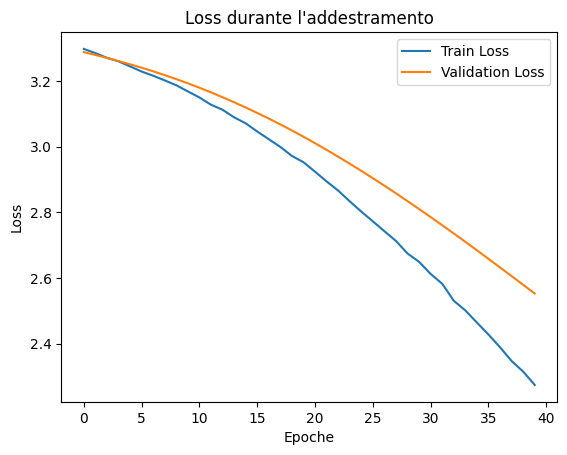

In [16]:
# grafico loss
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss durante l'addestramento")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.show()

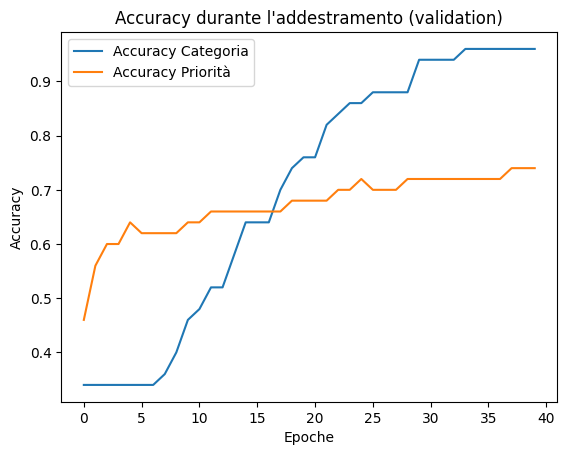

In [17]:
# grafico accuracy
plt.figure()
plt.plot(cat_accuracies, label="Accuracy Categoria")
plt.plot(prio_accuracies, label="Accuracy Priorità")
plt.title("Accuracy durante l'addestramento (validation)")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

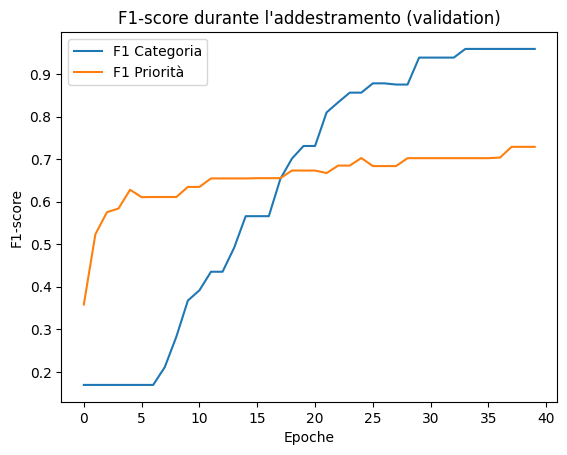

In [18]:
# grafico f1-score
plt.figure()
plt.plot(cat_f1_scores, label="F1 Categoria")
plt.plot(prio_f1_scores, label="F1 Priorità")
plt.title("F1-score durante l'addestramento (validation)")
plt.xlabel("Epoche")
plt.ylabel("F1-score")
plt.legend()
plt.show()

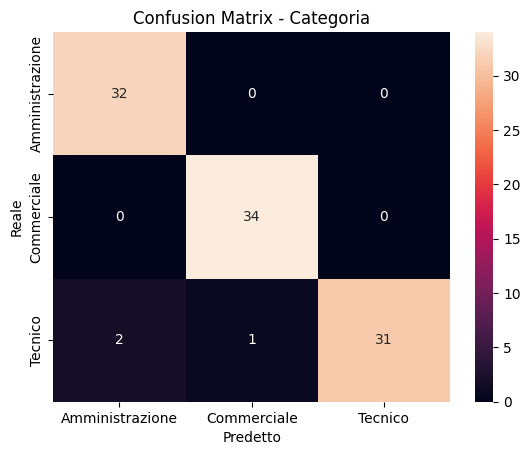

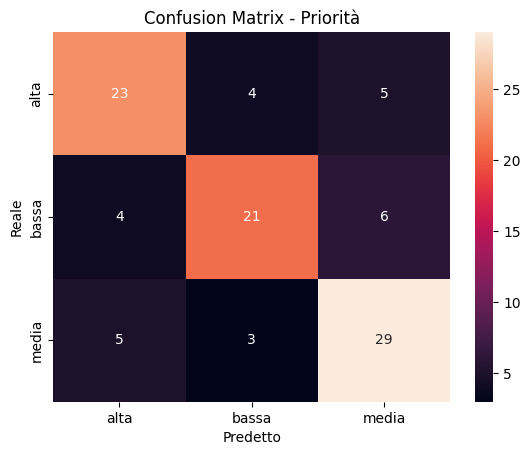

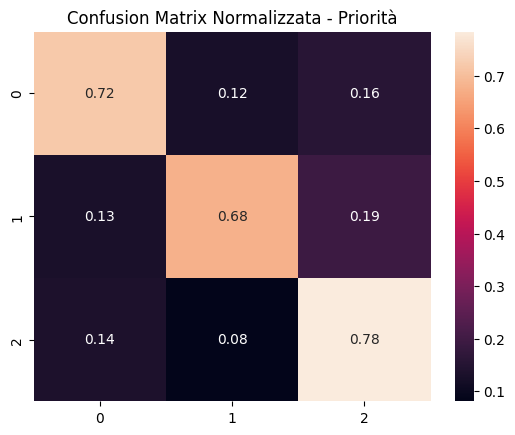

In [19]:
# confusion matrix - grafici
import matplotlib.pyplot as plt
import seaborn as sns

# Categoria
plt.figure()
sns.heatmap(cm_cat_df, annot=True, fmt="d")
plt.title("Confusion Matrix - Categoria")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.show()

# Priorità
plt.figure()
sns.heatmap(cm_prio_df, annot=True, fmt="d")
plt.title("Confusion Matrix - Priorità")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.show()

# Priorità normalizzata
cm_prio_norm = cm_prio.astype("float") / cm_prio.sum(axis=1)[:, None]

sns.heatmap(cm_prio_norm, annot=True, fmt=".2f")
plt.title("Confusion Matrix Normalizzata - Priorità")
plt.show()

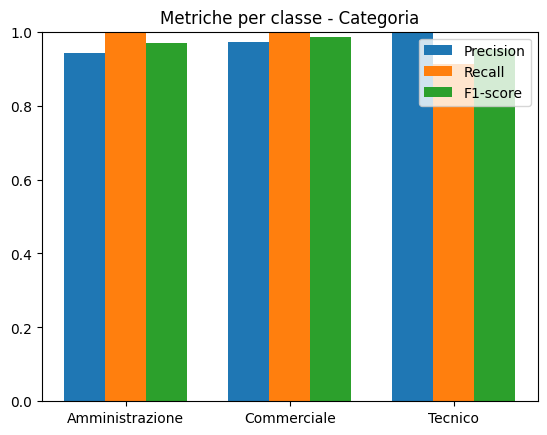

In [20]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

labels = list(le_cat.classes_)
report = classification_report(
    y_cat_test,
    cat_pred.numpy(),
    target_names=labels,
    output_dict=True)

precision = [report[label]["precision"] for label in labels]
recall = [report[label]["recall"] for label in labels]
f1 = [report[label]["f1-score"] for label in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure()

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Metriche per classe - Categoria")
plt.legend()

plt.show()

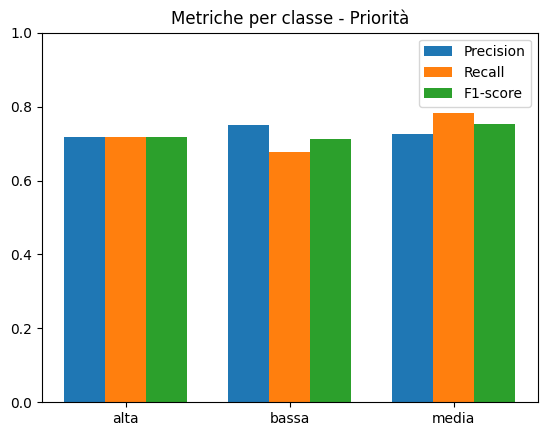

In [21]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

labels = list(le_prio.classes_)
report = classification_report(
    y_prio_test,
    prio_pred.numpy(),
    target_names=labels,
    output_dict=True)

precision = [report[label]["precision"] for label in labels]
recall = [report[label]["recall"] for label in labels]
f1 = [report[label]["f1-score"] for label in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure()

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Metriche per classe - Priorità")
plt.legend()

plt.show()

In [22]:
import numpy as np # Assicurati che numpy sia importato

def top_words(vec, linear_layer, n=5):
    # La funzione ora accetta direttamente un layer lineare
    weights = linear_layer.weight.detach().numpy()
    features = vectorizer.get_feature_names_out()

    idx = vec.nonzero()[1]
    # Calcola l'influenza sommando i valori assoluti dei pesi per ciascuna parola attiva
    scores = np.abs(weights[:, idx]).sum(axis=0)

    top_idx = np.argsort(scores)[-n:]
    print("idx",idx)
    print("scores",scores)

    return [features[idx[i]] for i in top_idx]


In [23]:
def top_words(vec, model, n=5):
    weights = model.weight.detach().numpy()
    features = vectorizer.get_feature_names_out()

    idx = vec.nonzero()[1]
    scores = weights[:, idx].sum(axis=0)

    top_idx = np.argsort(np.abs(scores))[-n:]
    return [features[idx[i]] for i in top_idx]


In [24]:
from IPython.display import display, clear_output
import ipywidgets as widgets

def predict_ticket(b):
    clear_output(wait=True)

    text = subject_input.value + " " + description_input.value

    if len(text.strip()) == 0:
        print("⚠️ Inserisci un testo")
        return

    vec = vectorizer.transform([text])
    vec = torch.tensor(vec.toarray(), dtype=torch.float32)

    with torch.no_grad():
        cat_output, prio_output = model(vec) # Chiamata corretta al modello unico
        cat_pred = torch.argmax(cat_output, dim=1).item()
        prio_pred = torch.argmax(prio_output, dim=1).item()

    cat_label = le_cat.inverse_transform([cat_pred])[0]
    prio_label = le_prio.inverse_transform([prio_pred])[0]

    print("📌 RISULTATO")
    print("Ticket:", text)
    print("Categoria:", cat_label)
    print("Priorità suggerita:", prio_label)
    # Passiamo il primo strato lineare del blocco 'shared' per le parole influenti
    print("Parole influenti:", ", ".join(top_words(vec, model.shared[0])))


In [25]:
subject_input = widgets.Text(
    description="Oggetto:",
    layout=widgets.Layout(width="80%")
)

description_input = widgets.Textarea(
    description="Descrizione:",
    layout=widgets.Layout(width="80%", height="100px")
)

predict_button = widgets.Button(
    description="Classifica Ticket",
    button_style="primary"
)

predict_button.on_click(predict_ticket)

display(subject_input, description_input, predict_button)

📌 RISULTATO
Ticket: richiesta prenotazione si richiede prenotazione museo per domani. grazie
Categoria: Commerciale
Priorità suggerita: bassa
Parole influenti: 00, grazie
